# Charging analysis based on trajectory data

In [34]:
import cudf
import cupy as cp
import pandas as pd
import numpy as np
import os
from pathlib import Path
from scipy.spatial import cKDTree
from heapq import heappush, heappop
import pyarrow.parquet as pq
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
import pickle
from sklearn.cluster import DBSCAN
import contextily as ctx

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")


In [2]:
# Haversine distance
def haversine_distance(lon1, lat1, lon2, lat2):
    lon1 = cp.asarray(lon1.values if hasattr(lon1, 'values') else lon1)
    lat1 = cp.asarray(lat1.values if hasattr(lat1, 'values') else lat1)
    lon2 = cp.asarray(lon2.values if hasattr(lon2, 'values') else lon2)
    lat2 = cp.asarray(lat2.values if hasattr(lat2, 'values') else lat2)

    lon1_rad = cp.radians(lon1.astype(cp.float64))
    lat1_rad = cp.radians(lat1.astype(cp.float64))
    lon2_rad = cp.radians(lon2.astype(cp.float64))
    lat2_rad = cp.radians(lat2.astype(cp.float64))

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = cp.sin(dlat / 2)**2 + cp.cos(lat1_rad) * cp.cos(lat2_rad) * cp.sin(dlon / 2)**2
    c = 2 * cp.arcsin(cp.sqrt(a))
    R = 6371000
    return c * R


## Parameters


In [3]:
# parameters about identifying charing
R_STATION = 200          # distance to station (m）
T_STAY = 600             # min stay duration (second)
T_GAP = 300              # max time interval (seconds) between consecutive points in range of a station
PASSENGER_THR = 0        # idle

# parameters about energy
CAP_KWH = 80             # battery capacity（kWh）
CONS_KWH_PER_KM = 0.2   # consumption rate（kWh/km）
AVG_SPEED_KMH = 20       # （km/h）, used for lost data estimation
CHG_EFFICIENCY = 1.0     # actual charging percentage

MAX_GAP_SECONDS = 300   #The data loss time (seconds) is 10 minutes, otherwise ignore energy consumption

# file path
TRACKS_DIR = '../data/taxi_trajectories.parquet'  # trajectory dict
STATION_CSV = 'station_information.csv'           # station
PILE_CSV = 'pile_rated_power.csv'                 # piles


# output path
OUTPUT_DIR = 'output_v5'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DIST_CHARGING_EVENTS_FILE = f'{OUTPUT_DIR}/distributed_charging_events.parquet'
CHAR_QUEUE_FILE = f'{OUTPUT_DIR}/char_queue.parquet'
ENERGY_CONS_FILE = f'{OUTPUT_DIR}/energy_consumption.parquet'
BATTERY_TRACE_FILE = f'{OUTPUT_DIR}/battery_trace.parquet'
CENT_CHARGING_EVENTS_FILE = f'{OUTPUT_DIR}/centralized_charging_events.parquet'
LOSS_EVENTS_FILE = f'{OUTPUT_DIR}/loss_events.parquet'

#taxiid
TAXIIDS_FILE = f'{OUTPUT_DIR}/newid_filter.pkl'

MAX_WORKERS = 8   # parallel processing


## Station data


In [4]:
stations_df = pd.read_csv(STATION_CSV, dtype={'station_id': np.int32})
piles_df = pd.read_csv(PILE_CSV, dtype={'station_id': np.int32, 'pile_id': np.int32})
# filter valid piles and stations
max_power = 60
valid_piles_df = piles_df[(piles_df['power'] > 0) & (piles_df['power'] <= max_power)].copy()

stat_pile_df = valid_piles_df.groupby('station_id').agg(
    num_piles=('power', 'count'),
    avg_power=('power', 'mean'),
    max_power=('power', 'max'),
    min_power=('power', 'min')
).reset_index()

# aggregation
stations_df = stations_df.merge(stat_pile_df, on='station_id', how='inner')
stations_df = stations_df[stations_df['num_piles'] > 0].copy()

print(f"there are {len(stations_df)} valid stations")


there are 1478 valid stations


In [5]:
# KDTree of stations
station_coords = stations_df[['longitude', 'latitude']].to_numpy()
station_tree = cKDTree(station_coords)
station_id_lookup = stations_df['station_id'].to_numpy()


# All taxis to process

In [6]:
def get_all_taxiids(tracks_dir):
    """从目录结构中提取所有taxiid"""
    tracks_path = Path(tracks_dir)
    if not tracks_path.exists():
        logging.error(f"轨迹数据目录不存在: {tracks_dir}")
        return []

    taxiids = []
    for item in tracks_path.iterdir():
        if item.is_dir() and item.name.startswith('taxiid='):
            taxiid = item.name.replace('taxiid=', '')
            taxiids.append(taxiid)

    return sorted(taxiids)


In [7]:
all_taxiids = get_all_taxiids(TRACKS_DIR)
logging.info(f"找到 {len(all_taxiids)} 辆车")

2025-11-26 15:15:34,597 | INFO | 找到 19495 辆车


In [6]:
with open(TAXIIDS_FILE, 'rb') as f:
    all_taxiids = pickle.load(f)
logging.info(f"find {len(all_taxiids)} taxis")

2025-11-26 13:43:39,376 | INFO | find 15302 taxis


In [141]:
pickle_path2 = f'output_v5/validid_filter.pkl'
with open(pickle_path2 , 'rb') as f:
    all_taxiids = pickle.load(f)
logging.info(f"find {len(all_taxiids)} taxis")

2025-12-02 14:50:02,146 | INFO | find 15853 taxis


# station_sz filter

In [95]:
sz_stations_df = pd.read_csv('matched_stations_info.csv')
len(sz_stations_df)

1791

In [91]:

# 1. 准备坐标数据 (将经纬度转为弧度)
coords = np.radians(sz_stations_df[['lat', 'lon']].values)

# 2. DBSCAN 聚类 (200米 = 0.2km, 地球半径约6371km)
# eps 是弧度距离: 0.2 / 6371
kms_per_radian = 6371.0088
epsilon = 0.5/ kms_per_radian

db = DBSCAN(eps=epsilon, min_samples=1, algorithm='ball_tree', metric='haversine').fit(coords)

# 3. 合并站点：按聚类标签分组，取平均值
merged_stations = sz_stations_df.groupby(db.labels_)[['lon', 'lat']].mean().reset_index(drop=True)

print(f"合并前: {len(sz_stations_df)} -> 合并后: {len(merged_stations)}")
# merged_stations 现在包含合并后的 lon, lat

合并前: 1791 -> 合并后: 695


In [45]:

def haversine_np(lon1, lat1, lon2, lat2):
    R = 6371000
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Load tables
chargestation_sz = pd.read_csv('chargestation_sz.csv')

# Get coordinate columns
stations_lon = next(col for col in stations_df.columns if any(k in col.lower() for k in ['经度', 'longitude', 'lon']))
stations_lat = next(col for col in stations_df.columns if any(k in col.lower() for k in ['纬度', 'latitude', 'lat']))
sz_lon = next(col for col in chargestation_sz.columns if any(k in col.lower() for k in ['经度', 'longitude', 'lon']))
sz_lat = next(col for col in chargestation_sz.columns if any(k in col.lower() for k in ['纬度', 'latitude', 'lat']))

# Build KDTree for station_information
station_coords = stations_df[[stations_lon, stations_lat]].values
station_tree = cKDTree(station_coords)

# Query nearest station for each chargestation_sz
sz_coords = chargestation_sz[[sz_lon, sz_lat]].values
distances_deg, nearest_indices = station_tree.query(sz_coords, k=1)

# Calculate distances in meters
nearest_station_coords = station_coords[nearest_indices]
distances_m = haversine_np(
    sz_coords[:, 0], sz_coords[:, 1],
    nearest_station_coords[:, 0], nearest_station_coords[:, 1]
)

# Filter: keep only stations with distance >= 200m
THRESHOLD = 200
sz_stations_df = chargestation_sz[distances_m >= THRESHOLD].copy()

print(f"Original: {len(chargestation_sz)} stations")
print(f"Filtered: {len(sz_stations_df)} stations (distance >= {THRESHOLD}m)")


Original: 4423 stations
Filtered: 2746 stations (distance >= 200m)


In [12]:
if 'station_id' not in sz_stations_df.columns:
    sz_stations_df['station_id'] = np.arange(1500,1500+len(sz_stations_df))
sz_stations_df.head()

,name,class,subcalss,lon,lat,province,city,district,station_id
0,杨梅坑专用停车场充电站,汽车相关,充电站,114.571256,22.544423,广东省,深圳市,龙岗区,1500
1,开迈斯汽车公共充电站,汽车相关,充电站,114.568624,22.545040,广东省,深圳市,龙岗区,1501
2,明天新能源公共充电站,汽车相关,充电站,114.518554,22.534409,广东省,深圳市,龙岗区,1502
3,南方和顺汽车公共充电站,汽车相关,充电站,114.528781,22.529354,广东省,深圳市,龙岗区,1503
4,云快充汽车公共充电站,汽车相关,充电站,114.518477,22.534385,广东省,深圳市,龙岗区,1504


# all station distribution

sz station: 695


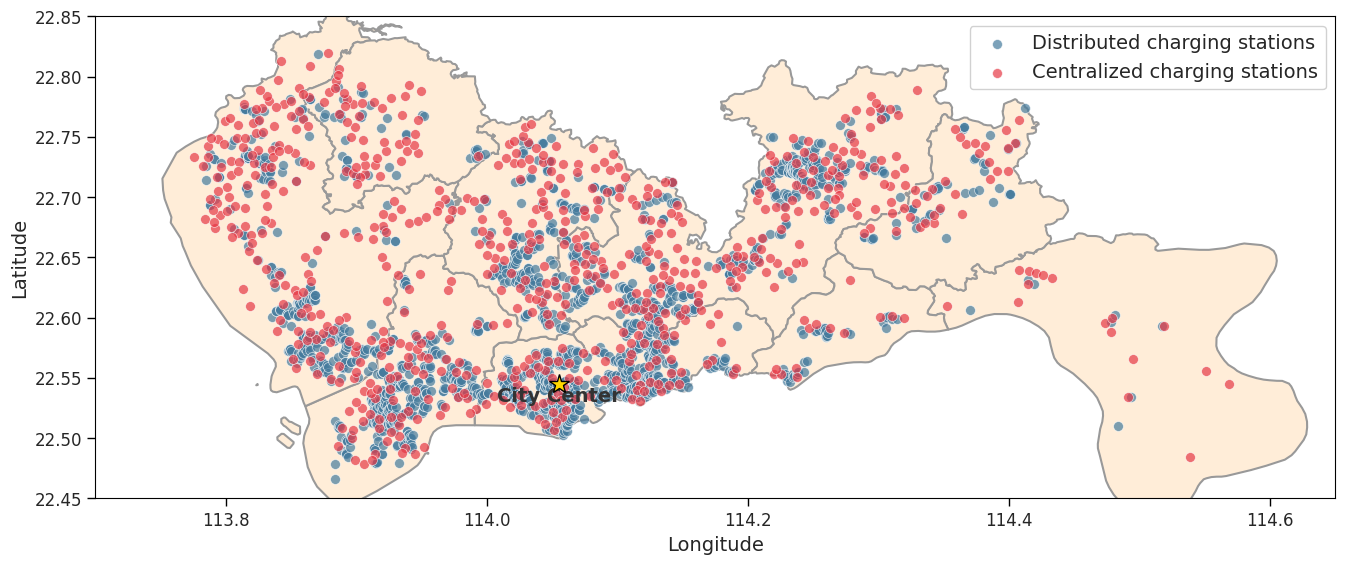

In [92]:
import matplotlib.ticker as ticker

# 1. 加载站点数据
stations_df = pd.read_csv('station_information.csv')
sz_stations_df = pd.read_csv('matched_stations_info.csv')
sz_stations_df = merged_stations.copy()
print('sz station:', len(sz_stations_df))
# 自动识别经纬度列
def get_cols(df):
    lon = [c for c in df.columns if 'lon' in c.lower() or '经度' in c][0]
    lat = [c for c in df.columns if 'lat' in c.lower() or '纬度' in c][0]
    return lon, lat

s_lon, s_lat = get_cols(stations_df)
sz_lon, sz_lat = get_cols(sz_stations_df)

# 2. 获取深圳轮廓 (阿里云 DataV)
boundary_file = 'shenzhen_full.json'
url = 'https://geo.datav.aliyun.com/areas_v3/bound/440300_full.json'

if not os.path.exists(boundary_file):
    try:
        print("正在下载深圳轮廓数据...")
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(boundary_file, 'wb') as f:
                f.write(r.content)
    except:
        pass

# 3. 手动构建“主要道路”骨架 (模拟真实路网，无需下载大文件)
# 包含：深南/滨河、北环、机荷高速、广深高速、梅观高速、龙岗大道等大致走向
roads_coords = [
    [(113.88, 22.54), (114.15, 22.54), (114.25, 22.55)], # 东西主干道 (深南/滨河)
    [(113.90, 22.57), (114.10, 22.58)], # 北环
    [(113.80, 22.68), (114.35, 22.72)], # 机荷/沈海高速
    [(113.92, 22.50), (113.85, 22.75)], # 广深高速
    [(114.05, 22.53), (114.04, 22.75)], # 梅观高速
    [(114.12, 22.55), (114.12, 22.65)], # 清平高速
    [(114.22, 22.55), (114.30, 22.75)], # 龙岗大道/水官
    [(113.80, 22.60), (114.00, 22.62)], # 宝石路/南光
]
main_roads = gpd.GeoDataFrame(geometry=[LineString(r) for r in roads_coords])

# 4. 开始绘图
# 计算比例：深圳中心纬度约 22.65度
aspect = np.cos(np.radians(22.65))
fig, ax = plt.subplots(figsize=(16, 16 * aspect)) # 宽16，高自动适应

# (A) 绘制深圳底图
if os.path.exists(boundary_file):
    sz_map = gpd.read_file(boundary_file)
    # 轮廓内底色 (浅橙色/肤色)
    sz_map.plot(ax=ax, color='#FFEDD8', edgecolor='#999999', linewidth=1.5, zorder=1)
else:
    # 备选：如果下载失败
    print("未找到轮廓文件，使用矩形代替")
    ax.set_facecolor('#FFEDD8')

# (B) 绘制主要道路 (深灰色线条)
#main_roads.plot(ax=ax, color='#888888', linewidth=2, alpha=0.6, zorder=2)

# (C) 绘制充电站 (气泡风格)
# 分散式 - 蓝色
ax.scatter(stations_df[s_lon], stations_df[s_lat],
           c='#457B9D', s=50, alpha=0.7,
           edgecolors='white', linewidths=0.5,
           label='Distributed charging stations', zorder=3)

# 集中式 - 红色
ax.scatter(sz_stations_df[sz_lon], sz_stations_df[sz_lat],
           c='#E63946', s=50, alpha=0.7,
           edgecolors='white', linewidths=0.5,
           label='Centralized charging stations', zorder=4)

# (D) 标注中心区 (City Center)
# 福田/罗湖大致位置
ax.text(114.055, 22.53, 'City Center', fontsize=14, fontweight='bold',
        ha='center', color='#333333', zorder=5)
ax.plot(114.055, 22.545, marker='*', color='gold', markersize=15, markeredgecolor='black', zorder=5)

# (E) 设置显示范围和比例
ax.set_xlim(113.70, 114.65)
ax.set_ylim(22.45, 22.85)
ax.set_aspect(aspect) # 修正纵横比，显示真实形状

# 确保四周的边框线是可见的
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')

ax.tick_params(axis='both', which='major', labelsize=12, direction='out', length=6, width=1, color='black',bottom=True, left=True, labelbottom=True, labelleft=True)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
# (F) 装饰
#ax.set_title('Distribution of Taxi Charging Stations in Shenzhen', fontsize=18, pad=20)
ax.legend(loc='upper right', fontsize=14, frameon=True, facecolor='white', framealpha=0.9)
ax.axis('on') # 关闭所有坐标轴和边框，只要地图
ax.grid(False)
ax.set_facecolor('white')

plt.show()

# Potential charging at centralized station

# GPS loss events

In [9]:
def detect_GPS_loss(taxiid, tracks_dir, gap_threshold=1800):
    try:
        # read trajectory data
        track_path = os.path.join(tracks_dir, f'taxiid={taxiid}')
        if not os.path.exists(track_path):
            return pd.DataFrame()

        track_files = list(Path(track_path).glob('*.parquet'))
        if not track_files:
            return pd.DataFrame()

        track = pd.concat([pd.read_parquet(f) for f in track_files], ignore_index=True)
        track = track.sort_values('time').reset_index(drop=True)

        if track.empty or len(track) < 2:
            return pd.DataFrame()

        # gap duration
        track['prev_time'] = track['time'].shift()
        track['prev_lon'] = track['lon'].shift()
        track['prev_lat'] = track['lat'].shift()
        track['dt'] = (track['time'] - track['prev_time']).dt.total_seconds()

        #gap duration  >= gap_threshold
        long_gaps = track[track['dt'] >= gap_threshold].copy()

        if long_gaps.empty:
            return pd.DataFrame()

        loss_events = []
        for idx, row in long_gaps.iterrows():
            loss_events.append({
                'taxiid': taxiid,
                'start_time': row['prev_time'],
                'end_time': row['time'],
                'duration_s': row['dt'],
                'start_lon': row['prev_lon'],
                'start_lat': row['prev_lat']
            })

        return pd.DataFrame(loss_events)

    except Exception as e:
        logging.error(f"erroe;{e} for {taxiid}")
        return pd.DataFrame()


def batch_detect_loss_events(all_taxiids, tracks_dir, output_file, gap_threshold=1800, max_workers=8):
    """

    """
    if os.path.exists(output_file):
        logging.info(f"{output_file} already exists")
        return pd.read_parquet(output_file)

    from concurrent.futures import ThreadPoolExecutor, as_completed

    all_loss_events = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(detect_GPS_loss, tid, tracks_dir, gap_threshold): tid
            for tid in all_taxiids
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="检测专用站充电事件"):
            taxiid = futures[future]
            try:
                result = future.result()
                if not result.empty:
                    all_loss_events.append(result)
            except Exception as e:
                logging.error(f"车辆 {taxiid} 处理失败: {e}")

    if all_loss_events:
        loss_events_df = pd.concat(all_loss_events, ignore_index=True)
        loss_events_df = loss_events_df.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        loss_events_df.to_parquet(output_file, index=False)
        logging.info(f"find {len(loss_events_df)} GPS loss enents, \
        covering {loss_events_df['taxiid'].nunique()} taxis,saved to {output_file}")
    else:
        logging.warning("No GPS loss events found")
        loss_events_df = pd.DataFrame()

    return loss_events_df

In [142]:
# get GPS loss events
if os.path.exists(LOSS_EVENTS_FILE):
    loss_events_df = pd.read_parquet(LOSS_EVENTS_FILE)
    loss_events_df = loss_events_df[loss_events_df['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"find {len(loss_events_df)} GPS loss events,covering {loss_events_df['taxiid'].nunique()} taxis")

else:
    GAP_THRESHOLD = 1800
    loss_events_df = batch_detect_loss_events(
        all_taxiids,
        TRACKS_DIR,
        LOSS_EVENTS_FILE,
        gap_threshold=GAP_THRESHOLD
    )
    loss_events_df = loss_events_df[loss_events_df['taxiid'].isin(all_taxiids)].copy()
    if not loss_events_df.empty:
        logging.info(f"find {len(loss_events_df)} GPS loss events, \
        covering {loss_events_df['taxiid'].nunique()} taxis")


2025-12-02 14:50:40,991 | INFO | find 315906 GPS loss events,covering 15853 taxis


# Identify charging events at centralized stations

# pre-process

In [97]:
# Define Shenzhen bounding box
SZ_BBOX = {
    'lon_min': 113.7,
    'lon_max': 114.7,
    'lat_min': 22.45,
    'lat_max': 22.85
}

# Filter vehicles - keep only those with all events within Shenzhen
loss_events_df['in_sz'] = (
    loss_events_df['start_lon'].between(SZ_BBOX['lon_min'], SZ_BBOX['lon_max']) &
    loss_events_df['start_lat'].between(SZ_BBOX['lat_min'], SZ_BBOX['lat_max']))

vehicles_with_outside_events = loss_events_df[~loss_events_df['in_sz']]['taxiid'].unique().tolist()
filtered_loss_events  = loss_events_df[~loss_events_df['taxiid'].isin(vehicles_with_outside_events)]
valid_vehicles = filtered_loss_events['taxiid'].unique().tolist()
print(f"Filtered vehicles: {len(valid_vehicles)}")
print(f"Filtered loss events: {len(filtered_loss_events)}")

# process stations
sz_station_coords = sz_stations_df[['lon','lat']].values
sz_station_tree = cKDTree(sz_station_coords)
sz_station_ids =  sz_stations_df['station_id'].values


Filtered vehicles: 15853
Filtered loss events: 315906


In [10]:
all_taxiids = valid_vehicles.copy()

# features of GPS loss events in Shenzhen

In [100]:
def haversine_np(lon1, lat1, lon2, lat2):
    """Calculate distance in meters for inputs in DEGREES"""
    R = 6371000
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# 1. Load & Prep Data
loss_events_df = filtered_loss_events.copy()
# Ensure input to DBSCAN is [lat, lon]
coords_lat_lon = loss_events_df[['start_lat', 'start_lon']].values

BATCH_SIZE = 50000
EPS_RAD = 500 / 6371000
MIN_SAMPLES = 3

# Shenzhen Boundary
SZ_BBOX = {'lon_min': 113.7, 'lon_max': 114.7, 'lat_min': 22.4, 'lat_max': 22.9}

batch_cluster_centers = []
total_noise = 0

# 2. Batch Clustering
n_batches = (len(coords_lat_lon) + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Processing {len(coords_lat_lon)} events in {n_batches} batches...")

for i in range(n_batches):
    start = i * BATCH_SIZE
    end = min((i + 1) * BATCH_SIZE, len(coords_lat_lon))
    batch_coords = coords_lat_lon[start:end] # [lat, lon]

    # DBSCAN (metric='haversine' expects [lat, lon] in radians)
    db = DBSCAN(eps=EPS_RAD, min_samples=MIN_SAMPLES, metric='haversine', algorithm='ball_tree')
    labels = db.fit_predict(np.radians(batch_coords))

    total_noise += (labels == -1).sum()

    # Calculate centers for this batch
    unique_labels = set(labels)
    unique_labels.discard(-1)

    for label in unique_labels:
        mask = (labels == label)
        points = batch_coords[mask] # [lat, lon]

        mean_lat = points[:, 0].mean()
        mean_lon = points[:, 1].mean()

        # Filter: Keep only centers within Shenzhen
        if (SZ_BBOX['lon_min'] <= mean_lon <= SZ_BBOX['lon_max'] and
            SZ_BBOX['lat_min'] <= mean_lat <= SZ_BBOX['lat_max']):

            # Store as [lon, lat] for consistency
            batch_cluster_centers.append([mean_lon, mean_lat])

print(f"Found {len(batch_cluster_centers)} valid cluster centers in Shenzhen.")



Processing 315906 events in 7 batches...
Found 1484 valid cluster centers in Shenzhen.


In [101]:
# 3. Merge Nearby Centers (Global)
if len(batch_cluster_centers) > 0:
    batch_centers_arr = np.array(batch_cluster_centers) # [lon, lat]

    # Convert to [lat, lon] radians for merging
    centers_rad = np.radians(batch_centers_arr[:, [1, 0]])

    # Merge centers within 200m
    MERGE_EPS = 200 / 6371000
    db_merge = DBSCAN(eps=MERGE_EPS, min_samples=1, metric='haversine', algorithm='ball_tree')
    merge_labels = db_merge.fit_predict(centers_rad)

    final_centers = []
    unique_merge_labels = set(merge_labels)

    for label in unique_merge_labels:
        mask = (merge_labels == label)
        points = batch_centers_arr[mask] # [lon, lat]

        mean_lon = points[:, 0].mean()
        mean_lat = points[:, 1].mean()
        final_centers.append([mean_lon, mean_lat])

    cluster_centers = np.array(final_centers)
    print(f"Final merged cluster centers: {len(cluster_centers)}")

else:
    cluster_centers = np.array([])
    print("No valid clusters found.")

Final merged cluster centers: 821


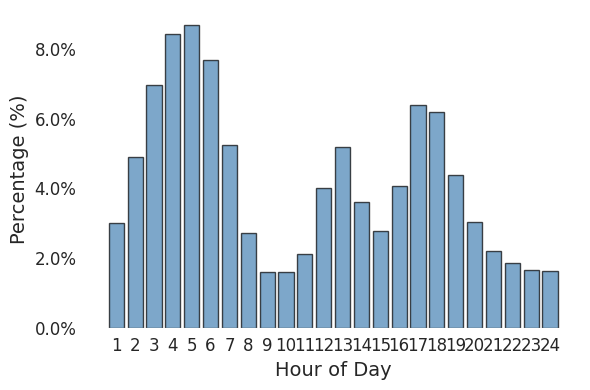

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 1. Load Data
df = pd.read_parquet('output_v5/loss_events.parquet')

# 2. Process Data
# Convert to datetime and extract hour
df['hour'] = pd.to_datetime(df['start_time']).dt.hour
# Count and sort
hourly_counts = df['hour'].value_counts().sort_index()
# Calculate Percentage
hourly_pct = (hourly_counts / len(df)) * 100

# Shift index from 0-23 to 1-24
hourly_pct.index = hourly_pct.index + 1

# === Font Size Settings ===
TITLE_SIZE = 14
LABEL_SIZE = 14
TICK_SIZE  = 12
# ==========================

# 3. Plot setup (Force white background)
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
ax.set_facecolor('white')

# 4. Draw Bars
ax.bar(hourly_pct.index, hourly_pct.values, color='steelblue', edgecolor='black', alpha=0.7)

# 5. Formatting
#ax.set_title('Temporal Distribution of GPS Loss Events (24h)', fontsize=TITLE_SIZE)
ax.set_xlabel('Hour of Day', fontsize=LABEL_SIZE)
ax.set_ylabel('Percentage (%)', fontsize=LABEL_SIZE)

# X-axis settings: 1 to 24
ax.set_xticks(range(1, 25))
ax.tick_params(axis='both', labelsize=TICK_SIZE)

# Y-axis settings: Percentage format
ax.yaxis.set_major_formatter(PercentFormatter(decimals=1))

# Remove grid for pure white, or keep light grid if preferred (comment out next line to remove grid completely)
#ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [102]:
import folium

# Create map
m = folium.Map(location=[22.6, 114.2], zoom_start=11, tiles='OpenStreetMap')

# 1. Draw Bounding Box (Blue Rectangle)
bounds = [[SZ_BBOX['lat_min'], SZ_BBOX['lon_min']],
          [SZ_BBOX['lat_max'], SZ_BBOX['lon_max']]]
folium.Rectangle(
    bounds=bounds,
    color="blue",
    weight=2,
    fill=False,
    popup="Valid Range"
).add_to(m)

# 2. Draw Stations (Green Circles, Hollow)
for _, row in merged_stations.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color='green',
        fill=False,  # Hollow
        weight=2,
        popup=f"Station {row.get('station_id', 'N/A')}"
    ).add_to(m)

# 3. Draw Cluster Centers (Red Circles, Hollow)
for i, center in enumerate(cluster_centers):
    folium.CircleMarker(
        location=[center[1], center[0]], # [lat, lon]
        radius=4,
        color='red',
        fill=False,  # Hollow
        weight=2,
        popup=f"Cluster {i+1}"
    ).add_to(m)

print(f"Map contains: {len(cluster_centers)} clusters, {len(merged_stations)} stations")
m

Map contains: 821 clusters, 695 stations


Stations: 695 -> 695 (inside SZ)
Clusters: 821 -> 779 (inside SZ)


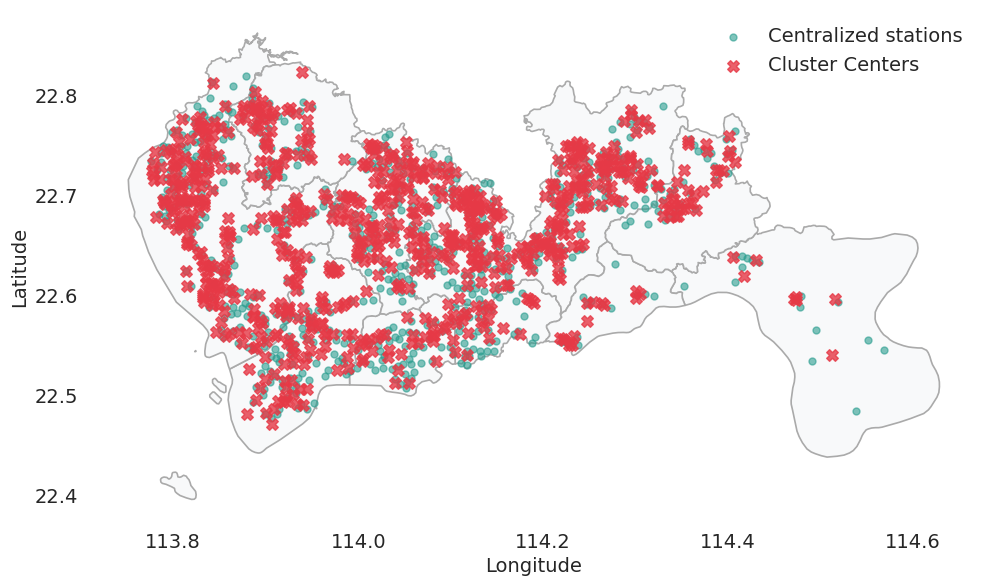

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import requests
import os
from shapely.geometry import Point

# 1. Get Shenzhen Boundary
boundary_file = 'shenzhen_full.json'
url = 'https://geo.datav.aliyun.com/areas_v3/bound/440300_full.json'

if not os.path.exists(boundary_file):
    try:
        print("Downloading Shenzhen boundary...")
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(boundary_file, 'wb') as f:
                f.write(r.content)
    except:
        pass

# Load map
if os.path.exists(boundary_file):
    sz_map = gpd.read_file(boundary_file)
else:
    print("Error: Boundary file not found.")
    # Create a dummy map if download fails (optional fallback)
    # sz_map = gpd.GeoDataFrame(...)

# 2. Prepare Data & Filter Points Inside Shenzhen
# Convert Stations to GeoDataFrame
stations_gdf = gpd.GeoDataFrame(
    merged_stations,
    geometry=gpd.points_from_xy(merged_stations.lon, merged_stations.lat),
    crs="EPSG:4326"
)

# Convert Cluster Centers to GeoDataFrame
# Ensure cluster_centers is a DataFrame with 'lon', 'lat'
if isinstance(cluster_centers, np.ndarray):
    cluster_df = pd.DataFrame(cluster_centers, columns=['lon', 'lat'])
else:
    cluster_df = pd.DataFrame(cluster_centers, columns=['lon', 'lat'])

clusters_gdf = gpd.GeoDataFrame(
    cluster_df,
    geometry=gpd.points_from_xy(cluster_df.lon, cluster_df.lat),
    crs="EPSG:4326"
)

# --- KEY STEP: Spatial Join to Filter Points ---
# Only keep points that are within the Shenzhen polygon
stations_in_sz = gpd.clip(stations_gdf, sz_map)
clusters_in_sz = gpd.clip(clusters_gdf, sz_map)

print(f"Stations: {len(stations_gdf)} -> {len(stations_in_sz)} (inside SZ)")
print(f"Clusters: {len(clusters_gdf)} -> {len(clusters_in_sz)} (inside SZ)")

# 3. Plotting
aspect = np.cos(np.radians(22.65))
fig, ax = plt.subplots(figsize=(10, 10 * aspect), facecolor='white')

# Draw Map Background (White/Light)
sz_map.plot(ax=ax, color='#f8f9fa', edgecolor='#aaaaaa', linewidth=1.2, zorder=1)

# Draw Stations (Teal dots)
ax.scatter(stations_in_sz.geometry.x, stations_in_sz.geometry.y,
           c='#2a9d8f', s=25, alpha=0.6,
           label=f'Centralized stations',
           zorder=2)

# Draw Cluster Centers (Red X)
ax.scatter(clusters_in_sz.geometry.x, clusters_in_sz.geometry.y,
           c='#e63946', s=70, alpha=0.8, marker='X',
           label=f'Cluster Centers',
           zorder=3)

# 4. Formatting
#ax.set_title('Clusters vs. Stations in Shenzhen', fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=14, frameon=False, facecolor='white', framealpha=0, shadow=False)

# Clean axis
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('white')
ax.tick_params(axis='both', which='major', labelsize=14)
# Remove grid
ax.grid(False)

plt.tight_layout()
plt.show()

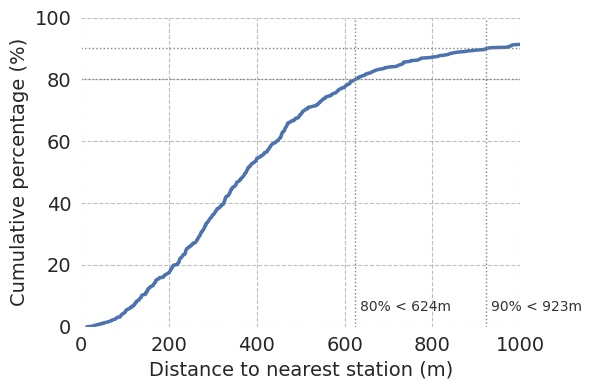

In [128]:
# ... (Distance calculation part remains same) ...

# 1. Prepare Data for CDF
sorted_data = np.sort(distances_m)
yvals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1) * 100  # Percent

# 2. Plot
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
ax.set_facecolor('white')

# Plot CDF line
ax.plot(sorted_data, yvals, color='#4c72b0', linewidth=2.5, label='CDF')

# 3. Formatting
plt.xlabel('Distance to nearest station (m)', fontsize=14)
plt.ylabel('Cumulative percentage (%)', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Limit x-axis to focus on relevant range (e.g., 0-1000m or slightly more)
plt.xlim(0, 1000) # Adjust as needed
plt.ylim(0, 100)

# Add Grid
plt.grid(True, linestyle='--', alpha=0.5, color='gray')

# Optional: Mark 80% or 90% line
for pct in [80, 90]:
    idx = np.searchsorted(yvals, pct)
    val = sorted_data[idx]
    plt.axhline(pct, color='gray', linestyle=':', linewidth=1)
    plt.axvline(val, color='gray', linestyle=':', linewidth=1)
    plt.text(val + 10, 5, f'{pct}% < {val:.0f}m', fontsize=10, color='#333333')

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# centralized station charging

In [143]:
if os.path.exists(CENT_CHARGING_EVENTS_FILE):
    cent_charging_events = pd.read_parquet(CENT_CHARGING_EVENTS_FILE)
    cent_charging_events = cent_charging_events[cent_charging_events['taxiid'].isin(all_taxiids)].copy()
    print(f"exist {CENT_CHARGING_EVENTS_FILE}, covering {cent_charging_events['taxiid'].nunique()} taxis, and {cent_charging_events['nearest_station_id'].nunique()} stations")
else:
    event_coords = filtered_loss_events[['start_lon', 'start_lat']].values
    distances_deg, nearest_indices = sz_station_tree.query(event_coords, k=1)

    nearest_station_ids = sz_station_ids[nearest_indices]
    nearest_station_coords = sz_station_coords[nearest_indices]

    # Calculate actual distances in meters
    distances_m = haversine_distance(
        filtered_loss_events['start_lon'].values,
        filtered_loss_events['start_lat'].values,
        nearest_station_coords[:, 0],
        nearest_station_coords[:, 1]
    )

    filtered_loss_events['nearest_station_id'] = nearest_station_ids
    filtered_loss_events['distance_to_station_m'] = distances_m.get()

    # Identify centralized charging events (distance < DIST_THRESHOLD(m))
    DIST_THRESHOLD = 500
    filtered_loss_events['is_cent_char'] = filtered_loss_events['distance_to_station_m'] < DIST_THRESHOLD
    cent_charging_events = filtered_loss_events[filtered_loss_events['is_cent_char']].copy()

    print(f"  Events within {DIST_THRESHOLD}m: {len(cent_charging_events)} ({len(cent_charging_events)/len(filtered_loss_events)*100:.2f}%)")

    # Save results
    cent_charging_events.to_parquet(CENT_CHARGING_EVENTS_FILE, index=False)
    print(f"\nSaved centralized charging events to: {CENT_CHARGING_EVENTS_FILE}, covering {cent_charging_events['taxiid'].nunique()} taxis, and {cent_charging_events['nearest_station_id'].nunique()} stations")

exist output_v5/centralized_charging_events.parquet, covering 15805 taxis, and 1742 stations


In [27]:

# Step 1: Get unique station IDs that matched charging events
matched_station_ids = cent_charging_events['nearest_station_id'].unique()

# Step 2: Extract station information for matched stations
# Check if sz_stations_df has 'station_id' column or uses index
if 'station_id' in sz_stations_df.columns:
    matched_stations = sz_stations_df[sz_stations_df['station_id'].isin(matched_station_ids)].copy()
elif sz_stations_df.index.name == 'station_id' or sz_stations_df.index.dtype in [np.int64, np.int32]:
    # If station_id is the index
    matched_stations = sz_stations_df.loc[sz_stations_df.index.isin(matched_station_ids)].copy()
else:
    # If no station_id column, create one from index
    sz_stations_df = sz_stations_df.copy()
    sz_stations_df['station_id'] = sz_stations_df.index
    matched_stations = sz_stations_df[sz_stations_df['station_id'].isin(matched_station_ids)].copy()


print(f"\nExtracted matched stations: {len(matched_stations)}")





Extracted matched stations: 1791


In [28]:
# Step 5: Save result
output_file = 'matched_stations_info.csv'
matched_stations.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\nSaved to: {output_file}")

# Display full info
print(f"\nFull matched stations info:")
print(matched_stations.head())


Saved to: matched_stations_info.csv

Full matched stations info:
              name class subcalss         lon        lat province city  \
1       开迈斯汽车公共充电站  汽车相关      充电站  114.568624  22.545040      广东省  深圳市   
14      比亚迪汽车公共充电站  汽车相关      充电站  114.473199  22.596834      广东省  深圳市   
15      象前充汽车公共充电站  汽车相关      充电站  114.473360  22.598727      广东省  深圳市   
16      深圳供电局公共充电站  汽车相关      充电站  114.478574  22.600642      广东省  深圳市   
32  充电有道长岭村汽车公共充电站  汽车相关      充电站  114.188342  22.552739      广东省  深圳市   

   district  station_id  
1       龙岗区        1501  
14      龙岗区        1514  
15      龙岗区        1515  
16      龙岗区        1516  
32      罗湖区        1520  


In [ ]:
# analysis to be done and visualization: gap loss events temporal-spatio features to determine possible charging, and after matching,
# we keep about 90% loss events that are close to a station (distribution of distance to station).

## Identify charging at distributed public stations

In [29]:
def detect_charging_for_one_taxi(taxiid, tracks_dir, station_tree, station_id_lookup, stations_df):

    try:
        # 读取轨迹数据
        track_path = os.path.join(tracks_dir, f'taxiid={taxiid}')
        if not os.path.exists(track_path):
            return pd.DataFrame()

        # 读取parquet文件（可能有多个分区文件）
        track_files = list(Path(track_path).glob('*.parquet'))
        if not track_files:
            return pd.DataFrame()

        # 读取并合并所有分区
        track = pd.concat([pd.read_parquet(f) for f in track_files], ignore_index=True)

        if track.empty:
            return pd.DataFrame()

        # 按时间排序
        track = track.sort_values('time').reset_index(drop=True)

        # 筛选空载点
        track = track[track['passenger'] == PASSENGER_THR].copy()

        if track.empty:
            return pd.DataFrame()

        # 查询最近充电站（CPU）
        track_coords = track[['lon', 'lat']].to_numpy()
        distances_deg, indices = station_tree.query(track_coords, k=1)
        distances_m = distances_deg * 111320  # 转换为米

        # 筛选在充电站半径内的点
        mask_in_station = distances_m <= R_STATION
        track_in_station = track[mask_in_station].copy()

        if track_in_station.empty:
            return pd.DataFrame()

        # 添加站点ID和距离信息
        track_in_station['nearest_station_id'] = station_id_lookup[indices[mask_in_station]]
        track_in_station['distance_to_station'] = distances_m[mask_in_station]

        # 按站点ID和时间排序
        track_in_station = track_in_station.sort_values(['nearest_station_id', 'time']).reset_index(drop=True)

        # 分段：同一站点内连续的点为一组
        # 如果时间间隔 > T_GAP 或站点ID变化，则断开
        track_in_station['prev_time'] = track_in_station.groupby('nearest_station_id')['time'].shift()
        track_in_station['prev_station'] = track_in_station['nearest_station_id'].shift()

        track_in_station['dt'] = (track_in_station['time'] - track_in_station['prev_time']).dt.total_seconds()
        track_in_station['station_changed'] = (track_in_station['nearest_station_id'] != track_in_station['prev_station'])

        # 标记段的开始（第一个点，或时间间隔过大，或站点变化）
        track_in_station['segment_start'] = (
            track_in_station['prev_time'].isna() |
            (track_in_station['dt'] > T_GAP) |
            track_in_station['station_changed']
        )

        # 分配段ID
        track_in_station['segment_id'] = track_in_station['segment_start'].cumsum()

        # 聚合每个段
        segments = track_in_station.groupby(['nearest_station_id', 'segment_id']).agg(
            start_time=('time', 'min'),
            end_time=('time', 'max'),
            stay_lon=('lon', 'mean'),
            stay_lat=('lat', 'mean'),
            num_points=('time', 'count'),
            avg_distance=('distance_to_station', 'mean')
        ).reset_index()

        # 计算持续时间
        segments['duration_s'] = (segments['end_time'] - segments['start_time']).dt.total_seconds()

        # 筛选满足最小停留时间的段
        charging_events = segments[segments['duration_s'] >= T_STAY].copy()

        # 添加taxiid
        charging_events['taxiid'] = taxiid

        # 选择输出列
        result = charging_events[['taxiid', 'nearest_station_id', 'start_time', 'end_time',
                                   'duration_s', 'stay_lon', 'stay_lat', 'num_points']].copy()

        return result

    except Exception as e:
        logging.error(f"处理车辆 {taxiid} 时出错: {e}")
        return pd.DataFrame()


In [144]:
# 如果文件已存在，可以选择跳过或重新计算
if os.path.exists(DIST_CHARGING_EVENTS_FILE):
    dist_charging_events = pd.read_parquet(DIST_CHARGING_EVENTS_FILE)
    dist_charging_events = dist_charging_events[dist_charging_events['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"充电事件文件已存在, has {len(dist_charging_events)} dist_events,涉及 {dist_charging_events['taxiid'].nunique()} 辆车")

else:
    # 批量处理
    dist_charging_events = []

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(detect_charging_for_one_taxi, tid, TRACKS_DIR,
                          station_tree, station_id_lookup, stations_df): tid
            for tid in all_taxiids
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="检测充电事件"):
            taxiid = futures[future]
            try:
                result = future.result()
                if not result.empty:
                    dist_charging_events.append(result)
            except Exception as e:
                logging.error(f"车辆 {taxiid} 处理失败: {e}")

    # 合并所有结果
    if dist_charging_events:
        dist_charging_events = pd.concat(dist_charging_events, ignore_index=True)
        dist_charging_events = dist_charging_events.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        dist_charging_events = dist_charging_events[dist_charging_events['taxiid'].isin(all_taxiids)].copy()
        # 保存结果
        dist_charging_events.to_parquet(DIST_CHARGING_EVENTS_FILE, index=False)
        logging.info(f"检测到 {len(dist_charging_events)} 个充电事件，涉及 {dist_charging_events['taxiid'].nunique()} 辆车,已保存到 {DIST_CHARGING_EVENTS_FILE}")
    else:
        logging.warning("未检测到任何充电事件")

2025-12-02 14:51:44,540 | INFO | 充电事件文件已存在, has 150038 dist_events,涉及 15707 辆车


In [145]:
# ========== 合并公共充电事件和专用站充电事件，用于后续能耗计算 ==========

if not dist_charging_events.empty:
    dist_charges_formatted = pd.DataFrame({
        'taxiid': dist_charging_events['taxiid'],
        'nearest_station_id': dist_charging_events['nearest_station_id'],
        'start_time': dist_charging_events['start_time'],
        'end_time': dist_charging_events['end_time'],
        'duration_s': dist_charging_events['duration_s'],
        'stay_lon': dist_charging_events['stay_lon'],
        'stay_lat': dist_charging_events['stay_lat'],
        'charge_type': 'distributed'
    })


if not cent_charging_events.empty:
    cent_charges_formatted = pd.DataFrame({
        'taxiid': cent_charging_events['taxiid'],
        'nearest_station_id': -1,  # 专用站充电标记为-1
        'start_time': cent_charging_events['start_time'],
        'end_time': cent_charging_events['end_time'],
        'duration_s': cent_charging_events['duration_s'],
        'stay_lon': cent_charging_events['start_lon'],
        'stay_lat': cent_charging_events['start_lat'],
        'charge_type': 'centralized'
    })


if not dist_charges_formatted.empty and not cent_charges_formatted.empty:
    all_charging_events = pd.concat([
        dist_charges_formatted,
        cent_charges_formatted
    ], ignore_index=True)
    logging.info(f"合并成功，总事件数: {len(all_charging_events)}")
else:
    logging.warning("没有找到任何充电事件")

if not all_charging_events.empty:
    all_charging_events = all_charging_events.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
    print(f"总事件数: {len(all_charging_events)}")
    print(f"\n涉及车辆数: {all_charging_events['taxiid'].nunique()}")


2025-12-02 14:51:52,998 | INFO | 合并成功，总事件数: 417051


总事件数: 417051

涉及车辆数: 15853


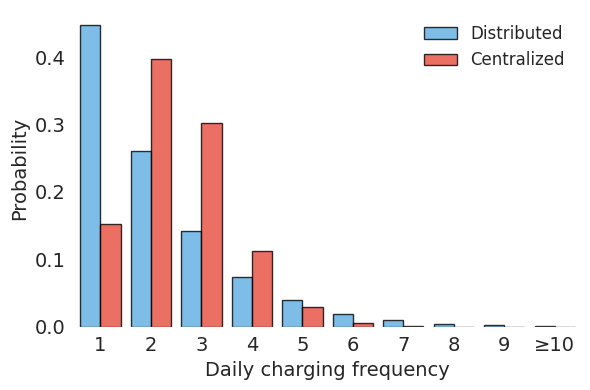

Average Daily Frequency:
charge_type
centralized    2.493794
distributed    2.138822
Name: freq, dtype: float64


In [139]:
#frequence of two types of charging

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'all_charging_events' is your merged DataFrame
# If it's not in memory, load it (or use the variable name you have)
# df = all_charging_events.copy()
df = all_charging_events.copy() # Use your variable name here

# 1. Preprocess
df['date'] = pd.to_datetime(df['start_time']).dt.date

# 2. Calculate Daily Frequency per Taxi per Type
# Count how many times each taxi charges per day for each type
daily_counts = df.groupby(['date', 'taxiid', 'charge_type']).size().reset_index(name='freq')
daily_counts['freq'] = daily_counts['freq'].clip(upper=10)
# 3. Calculate Probability Distribution
# We want to know: What % of taxi-days have 1 charge, 2 charges, etc.
dist_data = daily_counts.groupby(['charge_type', 'freq']).size().unstack(fill_value=0)
# Normalize to get probability (percentage)
dist_pct = dist_data.div(dist_data.sum(axis=1), axis=0)

# 4. Plot
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# Bar positions
x = dist_pct.columns
width = 0.4

# Plot Bars
if 'distributed' in dist_pct.index:
    ax.bar(x - width/2, dist_pct.loc['distributed'], width=width, label='Distributed',
           color='#5DADE2', edgecolor='black', alpha=0.8)

if 'centralized' in dist_pct.index:
    ax.bar(x + width/2, dist_pct.loc['centralized'], width=width, label='Centralized',
           color='#E74C3C', edgecolor='black', alpha=0.8)

# 5. Formatting
ax.set_xticks(range(1, 11))
xlabels = [str(i) for i in range(1, 10)] + ['≥10']
ax.set_xticklabels(xlabels)
ax.set_xlim(0.5, 10.5)
ax.set_xlabel('Daily charging frequency', fontsize=14)
ax.set_ylabel('Probability', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=12,frameon=False)
ax.set_facecolor('white')

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

# Print Average Frequency
avg_freq = daily_counts.groupby('charge_type')['freq'].mean()
print("Average Daily Frequency:")
print(avg_freq)

In [ ]:
# waiting time, charging time distribution, frequence

## Queue model


In [32]:
def simulate_queue(df):

    if df.empty:
        return pd.DataFrame()

    k = int(df['num_piles'].iloc[0])  # 充电桩数量
    busy_chargers_heap = []  # 最小堆，存储正在充电的车辆结束时间
    results = []

    for _, row in df.iterrows():
        arrival_time = row['start_time']
        departure_time = row['end_time']

        # 移除在当前车辆到达前已空闲的充电桩
        while busy_chargers_heap and busy_chargers_heap[0] <= arrival_time:
            heappop(busy_chargers_heap)

        # 检查是否有可用充电桩
        if len(busy_chargers_heap) < k:
            # 有空闲充电桩，无需等待
            wait_seconds = 0
            charge_start_time = arrival_time
        else:
            # 所有充电桩都忙，需要等待
            earliest_free_time = heappop(busy_chargers_heap)
            wait_seconds = (earliest_free_time - arrival_time).total_seconds()
            charge_start_time = earliest_free_time

        # 判断是否放弃充电
        stay_duration = (departure_time - arrival_time).total_seconds()
        gave_up = (wait_seconds >= stay_duration)

        # 计算实际充电时长
        if gave_up:
            actual_charge_seconds = 0
            # 如果放弃，把之前弹出的时间放回去
            if 'earliest_free_time' in locals() and wait_seconds > 0:
                heappush(busy_chargers_heap, earliest_free_time)
        else:
            actual_charge_seconds = (departure_time - charge_start_time).total_seconds()
            # 该车辆占用充电桩直到离开时间
            heappush(busy_chargers_heap, departure_time)

        results.append({
            'taxiid': row['taxiid'],
            'nearest_station_id': row['nearest_station_id'],
            'arrive_time': arrival_time,
            'leave_time': departure_time,
            'wait_dur': wait_seconds,
            'giveup': gave_up,
            'charge_dur': actual_charge_seconds
        })

    return pd.DataFrame(results)


In [14]:
# 执行排队模拟
if os.path.exists(CHAR_QUEUE_FILE):
    char_queue_df = pd.read_parquet(CHAR_QUEUE_FILE)
    char_queue_df = char_queue_df[char_queue_df['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"已加载排队模拟结果: {len(char_queue_df)} 条记录")

elif not dist_charging_events.empty:
    # 合并站点信息（获取num_piles）
    dist_charging_events = dist_charging_events[dist_charging_events['taxiid'].isin(all_taxiids)].copy()
    queue_input = dist_charging_events.merge(
        stations_df[['station_id', 'num_piles']],
        left_on='nearest_station_id',
        right_on='station_id',
        how='left'
    )

    # 按站点和时间排序
    queue_input = queue_input.sort_values(['nearest_station_id', 'start_time'], kind='mergesort')

    # 对每个站点进行排队模拟
    all_queue_results = []
    for station_id, group in tqdm(queue_input.groupby('nearest_station_id'), desc="排队模拟"):
        result = simulate_queue(group)
        if not result.empty:
            all_queue_results.append(result)

    # 合并结果
    if all_queue_results:
        char_queue_df = pd.concat(all_queue_results, ignore_index=True)
        char_queue_df = char_queue_df.sort_values(['taxiid', 'arrive_time']).reset_index(drop=True)
        # 保存结果
        char_queue_df.to_parquet(CHAR_QUEUE_FILE, index=False)
        logging.info(f"排队模拟完成，结果已保存到 {CHAR_QUEUE_FILE}")

        # 基本统计
        avg_wait = char_queue_df['wait_dur'].mean()
        giveup_rate = char_queue_df['giveup'].mean()
        logging.info(f"平均等待时间: {avg_wait:.2f} 秒 ({avg_wait/60:.2f} 分钟)")
        logging.info(f"放弃率: {giveup_rate:.2%}")
    else:
        logging.warning("排队模拟未产生结果")
        char_queue_df = pd.DataFrame()
else:
    logging.warning("充电事件数据不存在，无法进行排队模拟")


2025-11-27 11:12:20,520 | INFO | 已加载排队模拟结果: 150038 条记录


## Energy consumption and SOC trajectory

### energy consumption


In [34]:

def calculate_energy_between_charges_v2(tracks_dir, charging_events_taxi):

    try:
        # 从充电事件中获取taxiid
        if charging_events_taxi.empty or len(charging_events_taxi) < 2:
            return pd.DataFrame()

        taxiid = charging_events_taxi.iloc[0]['taxiid']

        # 读取轨迹数据
        track_path = os.path.join(tracks_dir, f'taxiid={taxiid}')
        if not os.path.exists(track_path):
            return pd.DataFrame()

        track_files = list(Path(track_path).glob('*.parquet'))
        if not track_files:
            return pd.DataFrame()

        # 读取轨迹（使用cudf加速）
        track = cudf.concat([cudf.read_parquet(f) for f in track_files], ignore_index=True)

        # 过滤zoneid < 0的点
        track = track[track['zoneid'] >= 0].copy()
        if track.empty:
            return pd.DataFrame()

        track = track.sort_values('time').reset_index(drop=True)

        # 计算相邻点之间的距离和时间差（向量化操作）
        track['prev_lon'] = track['lon'].shift()
        track['prev_lat'] = track['lat'].shift()
        track['prev_time'] = track['time'].shift()

        # 填充第一行的NaN（用自身值填充）
        track['prev_lon'] = track['prev_lon'].fillna(track['lon'])
        track['prev_lat'] = track['prev_lat'].fillna(track['lat'])
        track['prev_time'] = track['prev_time'].fillna(track['time'])

        # 计算时间差和距离
        track['dt'] = (track['time'] - track['prev_time']).dt.total_seconds()
        track['dist'] = haversine_distance(
            track['lon'], track['lat'],
            track['prev_lon'], track['prev_lat']
        )

        # 过滤异常跳点（速度 > 20 m/s，约72 km/h，对于城市出租车来说异常）
        track = track[track['dist'] / track['dt'].clip(lower=1) <= 15].copy()

        # 标记怠速点（速度 <= 5 km/h）
        track['idle'] = (track['velocity'] <= 5).astype('int8')

        # 转换为pandas（只在需要时转换）
        track_pd = track[['time', 'dt', 'dist', 'idle']].to_pandas()

        # 释放GPU内存
        del track
        cp._default_memory_pool.free_all_blocks()

        # 对每对相邻充电事件计算能耗
        results = []
        charging_events_sorted = charging_events_taxi.sort_values('start_time').reset_index(drop=True)

        for i in range(1, len(charging_events_sorted)):
            prev_end = charging_events_sorted.iloc[i - 1]['end_time']
            curr_start = charging_events_sorted.iloc[i]['start_time']
            curr_charge_type = charging_events_sorted.iloc[i]['charge_type']

            # 提取两次充电之间的轨迹段（使用布尔索引，更高效）
            mask = (track_pd['time'] > prev_end) & (track_pd['time'] <= curr_start)
            segment = track_pd[mask].copy()

            if segment.empty:
                continue

            # 检查数据缺失（时间间隔过大）
            large_gaps_mask = segment['dt'] > MAX_GAP_SECONDS
            missing_s = segment.loc[large_gaps_mask, 'dt'].sum() if large_gaps_mask.any() else 0

            # 只计算有数据的部分
            valid_segment = segment[~large_gaps_mask]
            if valid_segment.empty:
                continue

            # 计算行驶和怠速时间（向量化操作）
            drive_s = int(valid_segment.loc[valid_segment['idle'] == 0, 'dt'].sum())
            idle_s = int(valid_segment.loc[valid_segment['idle'] == 1, 'dt'].sum())
            gap_s = drive_s + idle_s

            # 计算距离和能耗
            distance_km = valid_segment['dist'].sum() / 1000
            energy_used_kWh = distance_km * CONS_KWH_PER_KM

            results.append({
                'taxiid': taxiid,
                'charge_start': curr_start,
                'prev_end': prev_end,
                'gap_s': gap_s,
                'drive_s': drive_s,
                'idle_s': idle_s,
                'distance_km': distance_km,
                'energy_used_kWh': energy_used_kWh,
                'missing_s': missing_s,
                'charge_type': curr_charge_type
            })

        return pd.DataFrame(results)

    except Exception as e:
        logging.error(f"计算车辆 {taxiid if 'taxiid' in locals() else 'unknown'} 能耗时出错: {e}")
        import traceback
        logging.error(traceback.format_exc())
        return pd.DataFrame()



In [15]:

# ========== 批量计算所有车辆的能耗（使用合并后的完整充电事件） ==========

# 如果文件已存在，可以选择跳过或重新计算
if os.path.exists(ENERGY_CONS_FILE):
    energy_cons_df = pd.read_parquet(ENERGY_CONS_FILE)
    energy_cons_df = energy_cons_df[energy_cons_df['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"能耗数据文件已存在: {ENERGY_CONS_FILE}")

else:
    all_energy_results = []
    all_charging_events =all_charging_events[all_charging_events['taxiid'].isin(all_taxiids)].copy()
    # 按车辆分组处理（使用groupby，更高效）
    grouped = all_charging_events.groupby('taxiid')

    for taxiid, ce_group in tqdm(grouped, total=grouped.ngroups, desc="计算能耗（含专用站充电）"):
        if len(ce_group) < 2:  # 至少需要2次充电才能计算间隔
            continue

        result = calculate_energy_between_charges_v2(TRACKS_DIR, ce_group)
        if not result.empty:
            all_energy_results.append(result)

        # 每处理100辆车释放一次GPU内存（减少释放频率，提高效率）
        if len(all_energy_results) % 100 == 0:
            cp._default_memory_pool.free_all_blocks()

    # 最终释放GPU内存
    cp._default_memory_pool.free_all_blocks()

    if all_energy_results:
        energy_cons_df = pd.concat(all_energy_results, ignore_index=True)
        energy_cons_df = energy_cons_df.sort_values(['taxiid', 'charge_start']).reset_index(drop=True)

        # 保存结果
        energy_cons_df.to_parquet(ENERGY_CONS_FILE, index=False)
        logging.info(f"能耗计算完成，结果已保存到 {ENERGY_CONS_FILE}")
    else:
        logging.warning("未计算出任何能耗数据")



2025-11-27 11:12:26,218 | INFO | 能耗数据文件已存在: output_v5/energy_consumption.parquet


# 6.2 SOC 轨迹

In [16]:
if os.path.exists(BATTERY_TRACE_FILE):
    battery_trace_output = pd.read_parquet(BATTERY_TRACE_FILE)
    battery_trace_output = battery_trace_output[battery_trace_output['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"{BATTERY_TRACE_FILE} exists, covering {battery_trace_output['taxiid'].nunique()} vehicles")

else:
    battery_trace = all_charging_events.copy()

    # 2. 分离公共和专用站充电事件
    public_mask = battery_trace['charge_type'] == 'distributed'
    dedicated_mask = battery_trace['charge_type'] == 'centralized'

    battery_trace_public = battery_trace[public_mask].copy()
    battery_trace_dedicated = battery_trace[dedicated_mask].copy()

    # 3. 处理公共充电事件：合并排队结果和站点功率
    if not battery_trace_public.empty:
        battery_trace_public = battery_trace_public.merge(
            char_queue_df[['taxiid', 'arrive_time', 'charge_dur', 'wait_dur', 'giveup']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'arrive_time'],
            how='left'
        )

        # 合并站点平均功率
        battery_trace_public = battery_trace_public.merge(
            stations_df[['station_id', 'avg_power']],
            left_on='nearest_station_id',
            right_on='station_id',
            how='left'
        )
        battery_trace_public = battery_trace_public.drop(columns=['station_id'], errors='ignore')

    # 4. 处理专用站充电事件：设置默认值
    if not battery_trace_dedicated.empty:
        battery_trace_dedicated['arrive_time'] = battery_trace_dedicated['start_time']
        battery_trace_dedicated['charge_dur'] = battery_trace_dedicated['duration_s']  # 全部都是充电时间
        battery_trace_dedicated['wait_dur'] = 0  # 专用站充电没有等待
        battery_trace_dedicated['giveup'] = False  # 专用站充电不放弃
        battery_trace_dedicated['avg_power'] = 43.0  # 专用站充电功率统一为43kW

    # 5. 合并公共和专用站充电事件
    if not battery_trace_public.empty and not battery_trace_dedicated.empty:
        # 统一列名
        common_cols = ['taxiid', 'nearest_station_id', 'start_time', 'end_time',
                      'duration_s', 'stay_lon', 'stay_lat', 'charge_type',
                      'arrive_time', 'charge_dur', 'wait_dur', 'giveup', 'avg_power']

        battery_trace = pd.concat([
            battery_trace_public[common_cols],
            battery_trace_dedicated[common_cols]
        ], ignore_index=True)


    if battery_trace.empty:
        logging.warning("没有充电事件数据，无法计算SOC轨迹")
    else:
        # 6. 按车辆和时间排序
        battery_trace = battery_trace.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        battery_trace['prev_end'] = battery_trace.groupby('taxiid')['end_time'].shift()

        # 7. 合并能耗数据（两次充电之间的能耗，包含charge_type）
        battery_trace = battery_trace.merge(
            energy_cons_df[['taxiid', 'charge_start', 'energy_used_kWh', 'missing_s',
                'gap_s', 'drive_s', 'idle_s', 'distance_km', 'charge_type']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'charge_start'],
            how='left',
            suffixes=('', '_from_energy')
        )

        # 使用能耗表中的charge_type（更准确，因为它标记的是当前充电事件的类型）
        battery_trace['charge_type'] = battery_trace['charge_type_from_energy'].fillna(battery_trace['charge_type'])
        battery_trace = battery_trace.drop(columns=['charge_type_from_energy', 'charge_start'], errors='ignore')

        # 8. 初始化能耗数据
        battery_trace['energy_used_kWh'] = battery_trace['energy_used_kWh'].fillna(0)

        # 9. 逐车递推SOC（先计算SOC_before，再计算充入电量）
        def calculate_soc_trace_v2(group):
            soc_before_list = []
            soc_after_list = []
            soc_prev = CAP_KWH  # 初始满电

            for _, row in group.iterrows():
                # 计算充电前SOC
                soc_before = max(0, soc_prev - row['energy_used_kWh'])
                soc_before_list.append(soc_before)

                # 计算充入电量（基于充电前SOC）
                charge_dur_hours = row['charge_dur'] / 3600

                # 公共充电：放弃充电的功率为0，否则使用站平均功率
                # 专用站充电：功率统一为43kW
                if row['giveup'] == True:
                    power_kw = 0
                else:
                    power_kw = row['avg_power'] if pd.notna(row['avg_power']) else 0

                # 计算理论充入电量
                energy_in_theoretical = charge_dur_hours * power_kw * CHG_EFFICIENCY

                # 限制充入电量：不能超过（满电量 - 充电前电量）
                max_energy_in = CAP_KWH - soc_before
                energy_in = min(energy_in_theoretical, max_energy_in)

                # 计算充电后SOC
                soc_after = min(CAP_KWH, soc_before + energy_in)
                soc_after_list.append(soc_after)

                soc_prev = soc_after

            group['SOC_before_kWh'] = soc_before_list
            group['SOC_after_kWh'] = soc_after_list
            group['energy_in_kWh'] = [soc_after_list[i] - soc_before_list[i] for i in range(len(soc_before_list))]
            return group

        battery_trace = battery_trace.groupby('taxiid', group_keys=False).apply(calculate_soc_trace_v2)

        # 10. 计算百分比
        battery_trace['SOC_before_pct'] = battery_trace['SOC_before_kWh'] / CAP_KWH * 100
        battery_trace['SOC_after_pct'] = battery_trace['SOC_after_kWh'] / CAP_KWH * 100

        # 11. 选择输出列（包含charge_type）
        output_cols = [
            'taxiid', 'charge_type', 'nearest_station_id', 'start_time', 'end_time',
            'SOC_before_kWh', 'SOC_after_kWh', 'SOC_before_pct', 'SOC_after_pct',
            'energy_used_kWh', 'energy_in_kWh',
            'distance_km', 'drive_s', 'idle_s', 'gap_s', 'missing_s',
            'charge_dur', 'wait_dur', 'giveup'
        ]
        output_cols = [col for col in output_cols if col in battery_trace.columns]
        battery_trace_output = battery_trace[output_cols].copy()
        battery_trace_output.to_parquet(BATTERY_TRACE_FILE, index=False)
        logging.info(f"covering {battery_trace_output['taxiid'].nunique()} vehicles, saved to {BATTERY_TRACE_FILE}")


2025-11-27 11:12:32,032 | INFO | output_v5/battery_trace.parquet exists, covering 15853 vehicles


In [18]:
# 假设 battery_trace_output 是你包含SOC轨迹的DataFrame

# 1. 找出所有存在 "充电前SOC < 1%" 记录的车辆ID (taxiid)
#    首先，筛选出所有不符合条件的记录
low_soc_events = battery_trace_output[battery_trace_output['SOC_before_pct'] < 0.1]

#    然后，获取这些记录对应的所有唯一的 taxiid
taxiids_to_exclude = low_soc_events['taxiid'].unique()

# 2. 从原始DataFrame中剔除这些车辆的所有记录
#    使用 .isin() 方法来判断每一行的 'taxiid' 是否在我们要排除的列表中
#    前面的 ~ 符号表示 "取反"，即保留那些 taxiid 不在排除列表中的行
filtered_df = battery_trace_output[~battery_trace_output['taxiid'].isin(taxiids_to_exclude)].copy()

# 3. 打印统计信息，验证筛选结果
original_taxi_count = battery_trace_output['taxiid'].nunique()
filtered_taxi_count = filtered_df['taxiid'].nunique()
removed_taxi_count = original_taxi_count - filtered_taxi_count

print("原始DataFrame信息：")
print(f"  总车辆数: {original_taxi_count}")
print(f"  总事件数: {len(battery_trace_output)}")

print(f"\n需要排除的车辆数: {len(taxiids_to_exclude)}")
print(f"  这些车辆是: {taxiids_to_exclude}")

print("\n筛选后DataFrame信息：")
print(f"  剩余车辆数: {filtered_taxi_count}")
print(f"  剩余事件数: {len(filtered_df)}")

print(f"\n共剔除了 {removed_taxi_count} 辆车的所有数据。")

# 新的DataFrame 'filtered_df' 现在可以用于后续分析
# 可以查看一下筛选后的结果
print("\n筛选后的DataFrame示例：")
print(filtered_df.head())

原始DataFrame信息：
  总车辆数: 15853
  总事件数: 417051

需要排除的车辆数: 0
  这些车辆是: []

筛选后DataFrame信息：
  剩余车辆数: 15853
  剩余事件数: 417051

共剔除了 0 辆车的所有数据。

筛选后的DataFrame示例：
      taxiid  charge_type  nearest_station_id          start_time  \
0  UUUB0C0M7  centralized                  -1 2020-01-01 04:17:29   
1  UUUB0C0M7  centralized                  -1 2020-01-01 16:18:31   
2  UUUB0C0M7  distributed                2266 2020-01-02 01:21:09   
3  UUUB0C0M7  centralized                  -1 2020-01-02 04:16:24   
4  UUUB0C0M7  centralized                  -1 2020-01-02 16:09:34   

             end_time  SOC_before_kWh  SOC_after_kWh  SOC_before_pct  \
0 2020-01-01 05:48:13       80.000000       80.00000      100.000000   
1 2020-01-01 17:47:47       48.762003       80.00000       60.952504   
2 2020-01-02 01:35:24       57.535850       59.19835       71.919813   
3 2020-01-02 05:41:39       52.392484       80.00000       65.490605   
4 2020-01-02 17:32:36       50.046223       80.00000       62.557779   



In [38]:
filterids = filtered_df['taxiid'].unique().tolist()

In [39]:
pickle_path2 = f'output_v5/validid_filter.pkl'
with open(pickle_path2, 'wb') as f:  # 注意是 'wb' (write binary)
    # 使用 pickle.dump() 将列表写入文件
    pickle.dump(filterids, f)

print(f"列表已成功保存为 Pickle 文件: {pickle_path2}")

列表已成功保存为 Pickle 文件: output_v5/validid_filter.pkl


In [50]:
target = cent_charging_events[cent_charging_events['taxiid'].isin(filterids)].copy()
use_sz_stats = target['nearest_station_id'].unique().tolist()

In [51]:
len(use_sz_stats)

2809

In [ ]:
pickle_path2 = f'output_v4/id_filter.pkl'
with open(pickle_path2, 'rb') as f:  # 注意是 'wb' (write binary)
    # 使用 pickle.dump() 将列表写入文件
    filterids= pickle.load(f)

## Leaving station

In [21]:

MAX_TRACKING_MINUTES = 30  # Only track 30 minutes after leaving
MAX_TRACKING_SECONDS = MAX_TRACKING_MINUTES * 60

# Time bins for distribution (in seconds)
TIME_BINS = [0, 300, 600, 1200, 1800, float('inf')]  # 0-5min, 5-10min, 10-20min, 20-30min, >30min
TIME_LABELS = ['0-5min', '5-10min', '10-20min', '20-30min', '>30min']

def get_pickup_time_after_charging(taxiid, charging_events, tracks_dir):
    """
    For each charging event, find the first pickup (passenger > 0) after leaving the station.
    Only track for MAX_TRACKING_MINUTES minutes.

    Returns: List of dicts with charge_type and pickup_delay_seconds
    """
    try:
        if charging_events.empty:
            return []

        # Load trajectory data for this vehicle
        track_path = Path(tracks_dir) / f'taxiid={taxiid}'
        if not track_path.exists():
            return []

        track_files = list(track_path.glob('*.parquet'))
        if not track_files:
            return []

        # Read and concatenate all trajectory files
        track_parts = []
        for f in track_files:
            try:
                df = pd.read_parquet(f, columns=['time', 'passenger'])
                if not df.empty:
                    track_parts.append(df)
            except Exception as e:
                logging.warning(f"{taxiid}: Failed to read {f.name}: {e}")
                continue

        if not track_parts:
            return []

        track_df = pd.concat(track_parts, ignore_index=True)

        # Ensure time is datetime - handle both datetime and numeric timestamps
        if not pd.api.types.is_datetime64_any_dtype(track_df['time']):
            # If time is numeric (Unix timestamp), convert to datetime
            if track_df['time'].dtype in [np.int64, np.int32, np.float64, np.float32]:
                track_df['time'] = pd.to_datetime(track_df['time'], unit='s', errors='coerce')
            else:
                track_df['time'] = pd.to_datetime(track_df['time'], errors='coerce')

        # Remove any invalid timestamps
        track_df = track_df[track_df['time'].notna()].copy()
        if track_df.empty:
            return []

        track_df = track_df.sort_values('time').reset_index(drop=True)

        # Find all pickup times (passenger > 0)
        pickup_mask = track_df['passenger'] > 0
        pickup_times = track_df.loc[pickup_mask, 'time'].values

        if len(pickup_times) == 0:
            # No pickups found, return None for all events
            return [{
                'taxiid': taxiid,
                'charge_type': row['charge_type'],
                'pickup_delay_seconds': None
            } for _, row in charging_events.iterrows()]

        # Ensure pickup_times is datetime64 array
        if not pd.api.types.is_datetime64_any_dtype(pd.Series(pickup_times)):
            pickup_times = pd.to_datetime(pickup_times, errors='coerce')
            pickup_times = pickup_times[pd.notna(pickup_times)]

        results = []
        for _, event in charging_events.iterrows():
            end_time = event['end_time']
            charge_type = event['charge_type']

            # Ensure end_time is datetime
            if not isinstance(end_time, pd.Timestamp):
                if pd.api.types.is_numeric_dtype(type(end_time)) or isinstance(end_time, (int, float)):
                    end_time = pd.to_datetime(end_time, unit='s', errors='coerce')
                else:
                    end_time = pd.to_datetime(end_time, errors='coerce')

            if pd.isna(end_time):
                results.append({
                    'taxiid': taxiid,
                    'charge_type': charge_type,
                    'pickup_delay_seconds': None
                })
                continue

            # Find first pickup after end_time using pandas operations (more robust)
            # Filter pickups after end_time
            after_mask = pickup_times > end_time
            if not after_mask.any():
                # No pickup found after this charging event
                results.append({
                    'taxiid': taxiid,
                    'charge_type': charge_type,
                    'pickup_delay_seconds': None
                })
                continue

            # Get the first pickup time after end_time
            pickup_time = pickup_times[after_mask][0]
            delay_seconds = (pickup_time - end_time).total_seconds()

            # Only count if within tracking window
            if delay_seconds <= MAX_TRACKING_SECONDS:
                results.append({
                    'taxiid': taxiid,
                    'charge_type': charge_type,
                    'pickup_delay_seconds': delay_seconds
                })
            else:
                # Pickup is beyond tracking window
                results.append({
                    'taxiid': taxiid,
                    'charge_type': charge_type,
                    'pickup_delay_seconds': None  # Beyond 30 minutes
                })

        return results

    except Exception as e:
        logging.error(f"{taxiid}: Error processing: {e}")
        import traceback
        logging.error(traceback.format_exc())
        return []


# Main analysis
print("=" * 60)
print("Analyzing pickup times after leaving charging stations")
print("=" * 60)

# Load charging events
if Path(BATTERY_TRACE_FILE).exists():
    battery_trace = pd.read_parquet(BATTERY_TRACE_FILE)
    #battery_trace = battery_trace[:2].copy()
    print(f"Loaded battery_trace: {len(battery_trace)} events")

    # Extract charging events with end_time and charge_type
    charging_events = battery_trace[['taxiid', 'end_time', 'charge_type']].copy()

    # Ensure end_time is datetime
    if not pd.api.types.is_datetime64_any_dtype(charging_events['end_time']):
        # Try to convert - handle both datetime strings and numeric timestamps
        if charging_events['end_time'].dtype in [np.int64, np.int32, np.float64, np.float32]:
            charging_events['end_time'] = pd.to_datetime(charging_events['end_time'], unit='s', errors='coerce')
        else:
            charging_events['end_time'] = pd.to_datetime(charging_events['end_time'], errors='coerce')

    # Remove rows with invalid end_time
    charging_events = charging_events[charging_events['end_time'].notna()].copy()

    print(f"Processing {charging_events['taxiid'].nunique()} vehicles")

    # Process each vehicle
    all_results = []
    grouped = charging_events.groupby('taxiid')

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(get_pickup_time_after_charging, taxiid, group, TRACKS_DIR): taxiid
            for taxiid, group in grouped
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing vehicles"):
            taxiid = futures[future]
            try:
                results = future.result()
                if results:
                    all_results.extend(results)
            except Exception as e:
                logging.error(f"{taxiid}: Task failed: {e}")

    # Convert to DataFrame
    results_df = pd.DataFrame(all_results)

    print(f"\nTotal events processed: {len(results_df)}")
    print(f"Events with pickup within 30min: {results_df['pickup_delay_seconds'].notna().sum()}")
    print(f"Events without pickup or beyond 30min: {results_df['pickup_delay_seconds'].isna().sum()}")

    # Categorize delays
    # For None values (no pickup or >30min), assign to '>30min' category
    results_df['delay_category'] = pd.cut(
        results_df['pickup_delay_seconds'].fillna(MAX_TRACKING_SECONDS + 1),
        bins=TIME_BINS,
        labels=TIME_LABELS,
        include_lowest=True
    )

    # Replace category for None values
    results_df.loc[results_df['pickup_delay_seconds'].isna(), 'delay_category'] = '>30min'

    # Count distribution by charge_type
    distribution = results_df.groupby(['charge_type', 'delay_category']).size().unstack(fill_value=0)
    distribution_pct = distribution.div(distribution.sum(axis=1), axis=0) * 100

    print("\n" + "=" * 60)
    print("Distribution of pickup times after leaving charging stations")
    print("=" * 60)
    print("\nCount:")
    print(distribution)
    print("\nPercentage:")
    print(distribution_pct.round(2))

    # Summary statistics
    print("\n" + "=" * 60)
    print("Summary Statistics (only for pickups within 30 minutes)")
    print("=" * 60)

    valid_delays = results_df[results_df['pickup_delay_seconds'].notna()]

    if len(valid_delays) > 0:
        for charge_type in ['distributed', 'centralized']:
            type_data = valid_delays[valid_delays['charge_type'] == charge_type]['pickup_delay_seconds']
            if len(type_data) > 0:
                print(f"\n{charge_type.capitalize()} charging:")
                print(f"  Count: {len(type_data)}")
                print(f"  Mean: {type_data.mean()/60:.2f} minutes")
                print(f"  Median: {type_data.median()/60:.2f} minutes")
                print(f"  Std: {type_data.std()/60:.2f} minutes")

    # Save results
    output_file = Path(OUTPUT_DIR) / 'pickup_delay_analysis.parquet'
    results_df.to_parquet(output_file, index=False)
    print(f"\nResults saved to: {output_file}")

    # Save distribution summary
    summary_file = Path(OUTPUT_DIR) / 'pickup_delay_distribution.csv'
    distribution.to_csv(summary_file)
    print(f"Distribution summary saved to: {summary_file}")

else:
    print(f"Error: {BATTERY_TRACE_FILE} not found")

Analyzing pickup times after leaving charging stations
Loaded battery_trace: 417051 events
Processing 15853 vehicles


Processing vehicles: 100%|██████████| 15853/15853 [06:41<00:00, 39.46it/s]



Total events processed: 417051
Events with pickup within 30min: 351369
Events without pickup or beyond 30min: 65682

Distribution of pickup times after leaving charging stations

Count:
delay_category  0-5min  5-10min  10-20min  20-30min  >30min
charge_type                                                
centralized     120573    33757     44834     25977   41872
distributed      90466    12340     14766      8656   23810

Percentage:
delay_category  0-5min  5-10min  10-20min  20-30min  >30min
charge_type                                                
centralized      45.16    12.64     16.79      9.73   15.68
distributed      60.30     8.22      9.84      5.77   15.87

Summary Statistics (only for pickups within 30 minutes)

Distributed charging:
  Count: 126228
  Mean: 4.78 minutes
  Median: 1.00 minutes
  Std: 7.21 minutes

Centralized charging:
  Count: 225141
  Mean: 7.47 minutes
  Median: 4.12 minutes
  Std: 8.29 minutes


/tmp/ipykernel_4974/3328837332.py:202: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distribution = results_df.groupby(['charge_type', 'delay_category']).size().unstack(fill_value=0)



Results saved to: output_v5/pickup_delay_analysis.parquet
Distribution summary saved to: output_v5/pickup_delay_distribution.csv


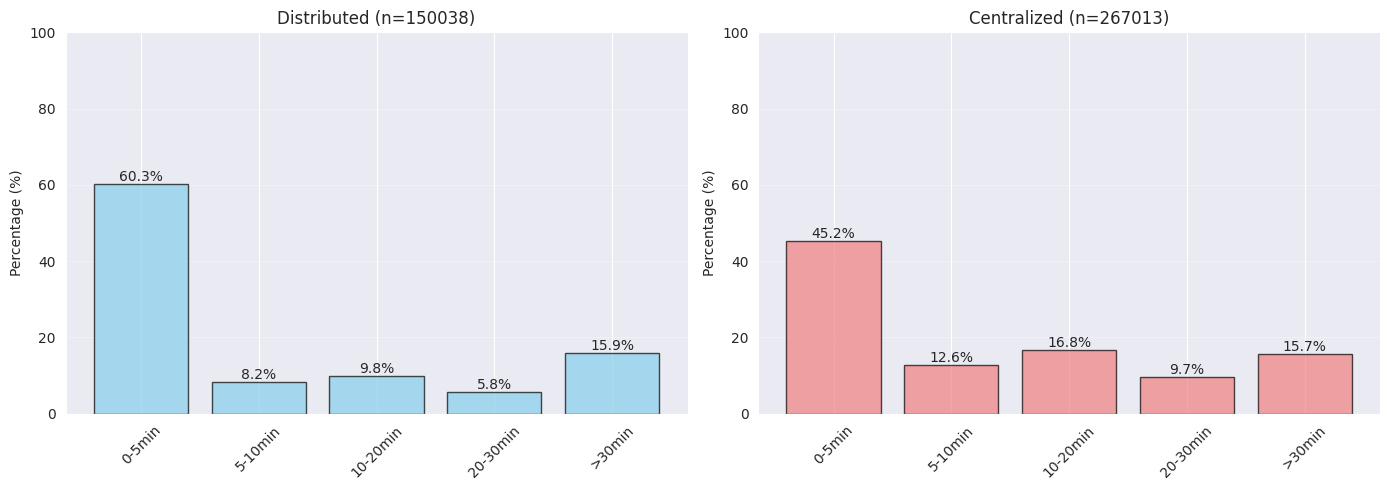

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
results_df = pd.read_parquet('output_v5/pickup_delay_analysis.parquet')

# Count distribution
distribution = results_df.groupby(['charge_type', 'delay_category'], observed=True).size().unstack(fill_value=0)
TIME_LABELS = ['0-5min', '5-10min', '10-20min', '20-30min', '>30min']

# Calculate percentages
distribution_pct = distribution.div(distribution.sum(axis=1), axis=0) * 100

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distributed
dist_pct = distribution_pct.loc['distributed', TIME_LABELS] if 'distributed' in distribution_pct.index else pd.Series(0, index=TIME_LABELS)
axes[0].bar(TIME_LABELS, dist_pct.values, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title(f'Distributed (n={distribution.loc["distributed"].sum() if "distributed" in distribution.index else 0})')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 100)
for i, v in enumerate(dist_pct.values):
    axes[0].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

# Centralized
cent_pct = distribution_pct.loc['centralized', TIME_LABELS] if 'centralized' in distribution_pct.index else pd.Series(0, index=TIME_LABELS)
axes[1].bar(TIME_LABELS, cent_pct.values, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title(f'Centralized (n={distribution.loc["centralized"].sum() if "centralized" in distribution.index else 0})')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 100)
for i, v in enumerate(cent_pct.values):
    axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

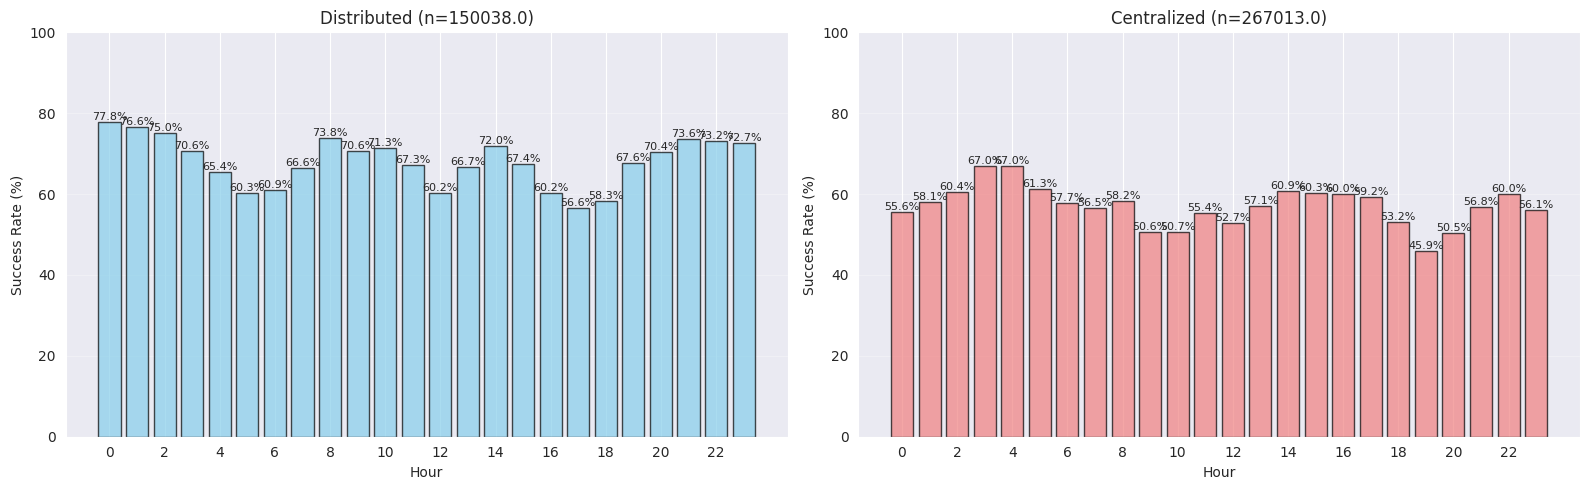


Success Rate by Hour (%):
hour            0      1      2      3      4      5      6      7      8   \
charge_type                                                                  
centralized  55.58  58.10  60.42  67.05  67.05  61.30  57.71  56.47  58.22   
distributed  77.76  76.57  74.99  70.62  65.42  60.27  60.95  66.57  73.84   

hour            9   ...     14     15     16     17     18     19     20  \
charge_type         ...                                                    
centralized  50.57  ...  60.87  60.26  59.95  59.24  53.22  45.93  50.46   
distributed  70.60  ...  71.95  67.45  60.22  56.60  58.26  67.57  70.39   

hour            21     22     23  
charge_type                       
centralized  56.81  59.95  56.13  
distributed  73.59  73.22  72.68  

[2 rows x 24 columns]


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
battery_trace = pd.read_parquet('output_v5/battery_trace.parquet')
results_df = pd.read_parquet('output_v5/pickup_delay_analysis.parquet')

# Extract hour
battery_trace['hour'] = pd.to_datetime(battery_trace['end_time']).dt.hour

# Mark events that found passengers within 30 min
results_df['found_30min'] = (
    (results_df['pickup_delay_seconds'].notna()) &
    (results_df['pickup_delay_seconds'] <= 600)
)

# Match by row number within (taxiid, charge_type) groups
battery_trace = battery_trace.sort_values(['taxiid', 'charge_type', 'end_time']).reset_index(drop=True)
battery_trace['row_num'] = battery_trace.groupby(['taxiid', 'charge_type']).cumcount()

results_df = results_df.sort_values(['taxiid', 'charge_type']).reset_index(drop=True)
results_df['row_num'] = results_df.groupby(['taxiid', 'charge_type']).cumcount()

# Merge
merged = battery_trace.merge(
    results_df[['taxiid', 'charge_type', 'row_num', 'found_30min']],
    on=['taxiid', 'charge_type', 'row_num'],
    how='left'
)
merged['found_30min'] = merged['found_30min'].fillna(False)

# Calculate success rate by hour
hourly = merged.groupby(['charge_type', 'hour'], observed=True).agg(
    total=('found_30min', 'count'),
    found=('found_30min', 'sum')
).reset_index()
hourly['rate'] = hourly['found'] / hourly['total'] * 100

# Pivot - use pivot_table or correct pivot syntax
rate_pivot = hourly.pivot_table(index='charge_type', columns='hour', values='rate', fill_value=0)
count_pivot = hourly.pivot_table(index='charge_type', columns='hour', values='total', fill_value=0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, charge_type in enumerate(['distributed', 'centralized']):
    if charge_type in rate_pivot.index:
        rate = rate_pivot.loc[charge_type]
        count = count_pivot.loc[charge_type]
        color = 'skyblue' if charge_type == 'distributed' else 'lightcoral'

        axes[idx].bar(rate.index, rate.values, color=color, edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel('Hour')
        axes[idx].set_ylabel('Success Rate (%)')
        axes[idx].set_title(f'{charge_type.capitalize()} (n={count.sum()})')
        axes[idx].set_xticks(range(0, 24, 2))
        axes[idx].set_ylim(0, 100)
        axes[idx].grid(True, alpha=0.3, axis='y')

        # Add labels
        for h, r in rate.items():
            if count[h] > 0:
                axes[idx].text(h, r, f'{r:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nSuccess Rate by Hour (%):")
print(rate_pivot.round(2))

## Results analysis
